# 451 Financial Engineering: Programming Assignment 1
## AAPL Return Prediction — v4 (Add RSI, MACD, 52-Week High Distance)

Michael Dawson

---





## Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pyarrow
import polars as pl

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, precision_score, recall_score, f1_score)

import xgboost as xgb
from xgboost import XGBRegressor

from scipy.stats import randint, uniform, spearmanr

import shap

## Load AAPL and Build Stationary Features (Same as v4)

In [2]:
aapl = pl.read_csv('aapl_historical_data.csv', try_parse_dates=True)
aapl = aapl.with_columns(pl.col('Date').cast(pl.Date))

drop_cols = [c for c in ['Dividends','Stock Splits','StockSplits','Capital Gains']
             if c in aapl.columns]
aapl = aapl.drop(drop_cols)

# core return
aapl = aapl.with_columns(np.log(pl.col('Close') / pl.col('Close').shift()).alias('LogReturn'))

# return lags
aapl = aapl.with_columns(pl.col('LogReturn').shift(1).alias('RetLag1'))
aapl = aapl.with_columns(pl.col('LogReturn').shift(2).alias('RetLag2'))
aapl = aapl.with_columns(pl.col('LogReturn').shift(3).alias('RetLag3'))

# HML% / OMC%
aapl = aapl.with_columns(((pl.col('High') - pl.col('Low')) / pl.col('Close')).alias('HMLpct'))
aapl = aapl.with_columns(((pl.col('Open') - pl.col('Close')) / pl.col('Close')).alias('OMCpct'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(1).alias('HMLpctLag1'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(2).alias('HMLpctLag2'))
aapl = aapl.with_columns(pl.col('HMLpct').shift(3).alias('HMLpctLag3'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(1).alias('OMCpctLag1'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(2).alias('OMCpctLag2'))
aapl = aapl.with_columns(pl.col('OMCpct').shift(3).alias('OMCpctLag3'))

# volume ratio
aapl = aapl.with_columns(pl.col('Volume').shift(1).alias('Vol_t1'))
aapl = aapl.with_columns(pl.col('Vol_t1').rolling_mean(window_size=20).alias('Vol20'))
aapl = aapl.with_columns((pl.col('Vol_t1') / pl.col('Vol20')).alias('VolRatioLag1'))
aapl = aapl.with_columns(pl.col('VolRatioLag1').shift(1).alias('VolRatioLag2'))
aapl = aapl.with_columns(pl.col('VolRatioLag1').shift(2).alias('VolRatioLag3'))

# return EMAs + realized vol
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=1, ignore_nulls=True).alias('RetEMA2'))
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=2, ignore_nulls=True).alias('RetEMA4'))
aapl = aapl.with_columns(pl.col('RetLag1').ewm_mean(half_life=4, ignore_nulls=True).alias('RetEMA8'))
aapl = aapl.with_columns(pl.col('RetLag1').rolling_std(window_size=20).alias('RetVol20'))

print('aapl rows after base features:', aapl.height)

aapl rows after base features: 4095


## NEW: Technical Indicators

All computed on `CloseLag1` (yesterday's close) or on `LogReturn.shift(1)` so same-day information never leaks.

### RSI(14)

Standard Wilder's RSI. Uses the rolling mean of up-moves vs down-moves over 14 days. Computing on lagged returns:

```
gain_t = max(RetLag1_t, 0)
loss_t = max(-RetLag1_t, 0)
avg_gain = rolling_mean(gain, 14)
avg_loss = rolling_mean(loss, 14)
RSI = 100 - 100 / (1 + avg_gain / avg_loss)
```

### MACD

`MACD = EMA_12(CloseLag1) − EMA_26(CloseLag1)`  
`MACD_Signal = EMA_9(MACD)`  
`MACD_Hist = MACD − MACD_Signal`

Note: MACD is on prices, which drift with the overall price level, so we normalize by dividing by `CloseLag1` — giving a scale-stable percentage form.

### 52-Week High Distance

`DistTo52wHigh = (CloseLag1 − 252-day rolling max of CloseLag1) / 252-day rolling max of CloseLag1`

Negative or zero. A value of -0.05 means the stock is 5% below its 52-week high.

In [3]:
# helper: lagged close for indicators
aapl = aapl.with_columns(pl.col('Close').shift(1).alias('CloseLag1'))

# --- RSI(14) ---
# use lagged returns so no leakage
aapl = aapl.with_columns(
    pl.when(pl.col('RetLag1') > 0).then(pl.col('RetLag1')).otherwise(0).alias('gain'),
    pl.when(pl.col('RetLag1') < 0).then(-pl.col('RetLag1')).otherwise(0).alias('loss'),
)
aapl = aapl.with_columns(
    pl.col('gain').rolling_mean(window_size=14).alias('avg_gain'),
    pl.col('loss').rolling_mean(window_size=14).alias('avg_loss'),
)
# avoid division by zero: if avg_loss == 0 and avg_gain > 0, RSI = 100; if both 0, RSI = 50
aapl = aapl.with_columns(
    pl.when(pl.col('avg_loss') == 0)
      .then(pl.when(pl.col('avg_gain') > 0).then(100.0).otherwise(50.0))
      .otherwise(100.0 - 100.0 / (1.0 + pl.col('avg_gain') / pl.col('avg_loss')))
      .alias('RSI_14')
)

# --- MACD ---
# traditional MACD uses EMA with span N where span ≈ 2/(N+1) for the smoothing factor.
# polars ewm_mean takes half_life; conversion: half_life = span * ln(2) / 2 works close enough.
# For clarity we use span directly via the `span` parameter.
aapl = aapl.with_columns(
    pl.col('CloseLag1').ewm_mean(span=12, ignore_nulls=True).alias('EMA12_close'),
    pl.col('CloseLag1').ewm_mean(span=26, ignore_nulls=True).alias('EMA26_close'),
)
# normalize MACD by CloseLag1 so it's scale-stable across the 15-year price range
aapl = aapl.with_columns(
    ((pl.col('EMA12_close') - pl.col('EMA26_close')) / pl.col('CloseLag1')).alias('MACD')
)
aapl = aapl.with_columns(
    pl.col('MACD').ewm_mean(span=9, ignore_nulls=True).alias('MACD_Signal')
)
aapl = aapl.with_columns(
    (pl.col('MACD') - pl.col('MACD_Signal')).alias('MACD_Hist')
)

# --- Distance to 52-week high ---
aapl = aapl.with_columns(
    pl.col('CloseLag1').rolling_max(window_size=252).alias('High52w')
)
aapl = aapl.with_columns(
    ((pl.col('CloseLag1') - pl.col('High52w')) / pl.col('High52w')).alias('DistTo52wHigh')
)

# --- regression target: 5-day forward log return ---
aapl = aapl.with_columns(
    np.log(pl.col('Close').shift(-4) / pl.col('Close').shift(1)).alias('Ret_5d_fwd')
)
aapl = aapl.with_columns(
    pl.when(pl.col('Ret_5d_fwd') > 0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target_5d')
)

print('aapl columns after technical indicators:')
for c in aapl.columns:
    print(' ', c)

aapl columns after technical indicators:
  Date
  Open
  High
  Low
  Close
  Volume
  LogReturn
  RetLag1
  RetLag2
  RetLag3
  HMLpct
  OMCpct
  HMLpctLag1
  HMLpctLag2
  HMLpctLag3
  OMCpctLag1
  OMCpctLag2
  OMCpctLag3
  Vol_t1
  Vol20
  VolRatioLag1
  VolRatioLag2
  VolRatioLag3
  RetEMA2
  RetEMA4
  RetEMA8
  RetVol20
  CloseLag1
  gain
  loss
  avg_gain
  avg_loss
  RSI_14
  EMA12_close
  EMA26_close
  MACD
  MACD_Signal
  MACD_Hist
  High52w
  DistTo52wHigh
  Ret_5d_fwd
  Target_5d


## Exogenous Features (Same as v4, no Nikkei)

In [4]:
def load_return_series(path, prefix):
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close']).rename({'Close': f'{prefix}_Close'})
    df = df.with_columns(
        np.log(pl.col(f'{prefix}_Close') / pl.col(f'{prefix}_Close').shift()).alias(f'{prefix}_Ret')
    )
    df = df.with_columns(pl.col(f'{prefix}_Ret').shift(1).alias(f'{prefix}_RetLag1'))
    return df.select(['Date', f'{prefix}_RetLag1'])

def load_vix(path):
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close']).rename({'Close': 'VIX_Close'})
    df = df.with_columns((pl.col('VIX_Close') - pl.col('VIX_Close').shift()).alias('VIX_Chg'))
    df = df.with_columns(pl.col('VIX_Close').shift(1).alias('VIX_LvlLag1'))
    df = df.with_columns(pl.col('VIX_Chg').shift(1).alias('VIX_ChgLag1'))
    return df.select(['Date', 'VIX_LvlLag1', 'VIX_ChgLag1'])

def load_tnx(path):
    df = pl.read_csv(path, try_parse_dates=True)
    df = df.with_columns(pl.col('Date').cast(pl.Date))
    df = df.select(['Date', 'Close']).rename({'Close': 'TNX_Close'})
    df = df.with_columns((pl.col('TNX_Close') - pl.col('TNX_Close').shift()).alias('TNX_Chg'))
    df = df.with_columns(pl.col('TNX_Chg').shift(1).alias('TNX_ChgLag1'))
    return df.select(['Date', 'TNX_ChgLag1'])

spy  = load_return_series('spy_historical_data.csv',  'SPY')
qqq  = load_return_series('qqq_historical_data.csv',  'QQQ')
soxx = load_return_series('soxx_historical_data.csv', 'SOXX')
tsm  = load_return_series('tsm_historical_data.csv',  'TSM')
xlk  = load_return_series('xlk_historical_data.csv',  'XLK')
vix  = load_vix('vix_historical_data.csv')
tnx  = load_tnx('tnx_historical_data.csv')

for name, df in [('SPY',spy),('QQQ',qqq),('SOXX',soxx),('TSM',tsm),
                 ('XLK',xlk),('VIX',vix),('TNX',tnx)]:
    print(f'{name:5s}  rows: {df.height}')

aapl = aapl.join(spy,  on='Date', how='left')
aapl = aapl.join(qqq,  on='Date', how='left')
aapl = aapl.join(soxx, on='Date', how='left')
aapl = aapl.join(tsm,  on='Date', how='left')
aapl = aapl.join(xlk,  on='Date', how='left')
aapl = aapl.join(vix,  on='Date', how='left')
aapl = aapl.join(tnx,  on='Date', how='left')

aapl = aapl.drop_nulls()
print()
print(f'final rows: {aapl.height}')
print(f'date range: {aapl["Date"].min()} to {aapl["Date"].max()}')

SPY    rows: 4095
QQQ    rows: 4095
SOXX   rows: 4095
TSM    rows: 4095
XLK    rows: 4095
VIX    rows: 4095
TNX    rows: 4093

final rows: 3838
date range: 2011-01-03 to 2026-04-09


## Train / Hold-Out Split

In [5]:
HOLDOUT_FRAC = 0.15
GAP = 10

n_total   = int(aapl.height)
n_holdout = int(HOLDOUT_FRAC * n_total)
n_train   = n_total - n_holdout - GAP

train   = aapl.slice(0, n_train)
holdout = aapl.slice(n_train + GAP, n_holdout)

print(f'train:   {train.height} rows   ({train["Date"].min()} to {train["Date"].max()})')
print(f'holdout: {holdout.height} rows   ({holdout["Date"].min()} to {holdout["Date"].max()})')

train:   3253 rows   (2011-01-03 to 2023-12-06)
holdout: 575 rows   (2023-12-21 to 2026-04-09)


## Feature Matrix

Drop raw OHLCV, same-day derived columns, and intermediate calculation columns from the feature matrix. Keep the lagged/rolling stationary features, the new technical indicators, and the exogenous set.

In [6]:
feature_drop = ['Date','Open','High','Low','Close','Volume',
                'LogReturn','Ret_5d_fwd','Target_5d',
                'HMLpct','OMCpct','Vol_t1','Vol20',
                'CloseLag1','gain','loss','avg_gain','avg_loss',
                'EMA12_close','EMA26_close','High52w']

X_train_df   = train.drop(feature_drop)
X_holdout_df = holdout.drop(feature_drop)

featureNames = X_train_df.columns
print(f'{len(featureNames)} features:')
for f in featureNames:
    print(f'  {f}')

y_train   = np.array(train['Ret_5d_fwd'])
y_holdout = np.array(holdout['Ret_5d_fwd'])
y_train_bin   = np.array(train['Target_5d'])
y_holdout_bin = np.array(holdout['Target_5d'])

29 features:
  RetLag1
  RetLag2
  RetLag3
  HMLpctLag1
  HMLpctLag2
  HMLpctLag3
  OMCpctLag1
  OMCpctLag2
  OMCpctLag3
  VolRatioLag1
  VolRatioLag2
  VolRatioLag3
  RetEMA2
  RetEMA4
  RetEMA8
  RetVol20
  RSI_14
  MACD
  MACD_Signal
  MACD_Hist
  DistTo52wHigh
  SPY_RetLag1
  QQQ_RetLag1
  SOXX_RetLag1
  TSM_RetLag1
  XLK_RetLag1
  VIX_LvlLag1
  VIX_ChgLag1
  TNX_ChgLag1


## Scale

In [7]:
scaler = StandardScaler()
X_train   = scaler.fit_transform(np.array(X_train_df))
X_holdout = scaler.transform(np.array(X_holdout_df))
print('X_train:',   X_train.shape)
print('X_holdout:', X_holdout.shape)

X_train: (3253, 29)
X_holdout: (575, 29)


## Model Comparison — Regression (Same as v4)

In [8]:
tscv = TimeSeriesSplit(n_splits=5, gap=10)

ridge_dist = {'alpha': uniform(0.001, 10.0)}
ridge_search = RandomizedSearchCV(
    Ridge(), ridge_dist, n_iter=20,
    scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
)
ridge_search.fit(X_train, y_train)
print(f'Ridge    — CV MSE: {-ridge_search.best_score_:.6f}')

rf_dist = {
    'n_estimators':     randint(200, 800),
    'max_depth':        randint(3, 15),
    'min_samples_leaf': randint(1, 20),
    'max_features':     ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_dist, n_iter=40,
    scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
)
rf_search.fit(X_train, y_train)
print(f'RF       — CV MSE: {-rf_search.best_score_:.6f}')

xgb_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(2, 8),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'reg_alpha':        uniform(0.0, 1.0),
    'reg_lambda':       uniform(0.0, 1.0),
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', tree_method='hist', random_state=42),
    xgb_dist, n_iter=50,
    scoring='neg_mean_squared_error', cv=tscv, n_jobs=-1, random_state=42, verbose=0,
)
xgb_search.fit(X_train, y_train)
print(f'XGBoost  — CV MSE: {-xgb_search.best_score_:.6f}')

Ridge    — CV MSE: 0.001463
RF       — CV MSE: 0.001448
XGBoost  — CV MSE: 0.001444


## Holdout Evaluation

In [9]:
def reg_holdout_metrics(model, name):
    pred = model.predict(X_holdout)
    rmse = np.sqrt(mean_squared_error(y_holdout, pred))
    mae  = mean_absolute_error(y_holdout, pred)
    r2   = r2_score(y_holdout, pred)
    ic, _ = spearmanr(pred, y_holdout)
    dir_acc = (np.sign(pred) == np.sign(y_holdout)).mean()
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'IC': ic, 'DirAcc0': dir_acc}

reg_results = [
    reg_holdout_metrics(ridge_search.best_estimator_, 'Ridge'),
    reg_holdout_metrics(rf_search.best_estimator_,    'Random Forest'),
    reg_holdout_metrics(xgb_search.best_estimator_,   'XGBoost'),
]

print('HOLDOUT REGRESSION METRICS (v5)')
print('-' * 70)
print(f'{"model":16s} {"RMSE":>8s} {"MAE":>8s} {"R²":>8s} {"IC":>8s} {"DirAcc0":>8s}')
for r in reg_results:
    print(f'{r["model"]:16s} {r["RMSE"]:8.5f} {r["MAE"]:8.5f} '
          f'{r["R²"]:+8.4f} {r["IC"]:+8.4f} {r["DirAcc0"]:8.4f}')

maj_class = int(y_train_bin.mean() > 0.5)
maj_acc = (y_holdout_bin == maj_class).mean()
print()
print(f'Majority-class direction accuracy baseline: {maj_acc:.4f}')

HOLDOUT REGRESSION METRICS (v5)
----------------------------------------------------------------------
model                RMSE      MAE       R²       IC  DirAcc0
Ridge             0.04041  0.03004  -0.0150  +0.0082   0.4904
Random Forest     0.03996  0.02973  +0.0072  +0.0458   0.5374
XGBoost           0.04012  0.02989  -0.0005  -0.0052   0.5252

Majority-class direction accuracy baseline: 0.5322


## Threshold Tuning 

best regressor by holdout IC: Random Forest
best threshold (OOF):   -0.020522
OOF accuracy at best t: 0.5841
OOF accuracy at t=0:    0.5568


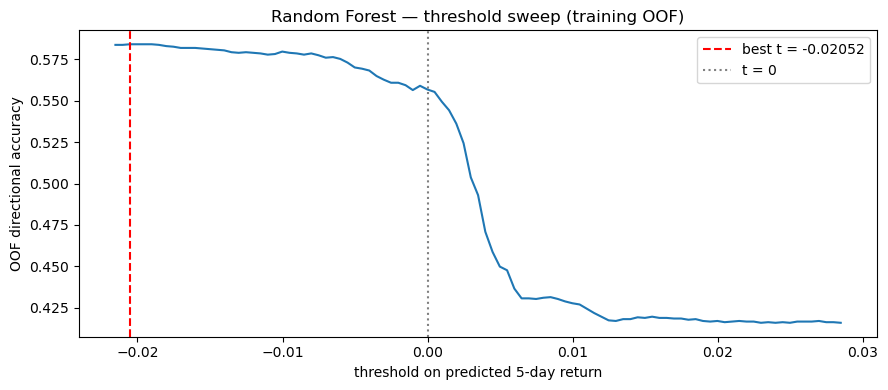

In [10]:
best_reg_name = max(reg_results, key=lambda r: r['IC'])['model']
reg_lookup = {
    'Ridge':         ridge_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'XGBoost':       xgb_search.best_estimator_,
}
best_reg = reg_lookup[best_reg_name]
print(f'best regressor by holdout IC: {best_reg_name}')

oof_pred = np.full(len(y_train), np.nan)
for tr_idx, te_idx in tscv.split(X_train):
    m = clone(best_reg)
    m.fit(X_train[tr_idx], y_train[tr_idx])
    oof_pred[te_idx] = m.predict(X_train[te_idx])
valid = ~np.isnan(oof_pred)

thresholds = np.linspace(oof_pred[valid].min(), oof_pred[valid].max(), 101)
dir_accs = [((oof_pred[valid] > t) == (y_train[valid] > 0)).mean() for t in thresholds]
dir_accs = np.array(dir_accs)
best_t = thresholds[int(np.argmax(dir_accs))]

print(f'best threshold (OOF):   {best_t:+.6f}')
print(f'OOF accuracy at best t: {dir_accs.max():.4f}')
print(f'OOF accuracy at t=0:    {dir_accs[np.argmin(np.abs(thresholds))]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresholds, dir_accs)
plt.axvline(best_t, linestyle='--', color='red', label=f'best t = {best_t:+.5f}')
plt.axvline(0, linestyle=':', color='gray', label='t = 0')
plt.xlabel('threshold on predicted 5-day return')
plt.ylabel('OOF directional accuracy')
plt.title(f'{best_reg_name} — threshold sweep (training OOF)')
plt.legend()
plt.tight_layout()
plt.show()

## Apply Tuned Threshold to Holdout

HOLDOUT DIRECTIONAL ACCURACY (v5)
--------------------------------------------------
Majority-class baseline:           0.5322
Threshold = 0:                     0.5374
Threshold = -0.02052 (tuned):  0.5339

confusion matrix (tuned threshold):
[[  1 268]
 [  0 306]]

precision: 0.5331
recall:    1.0000
f1:        0.6955


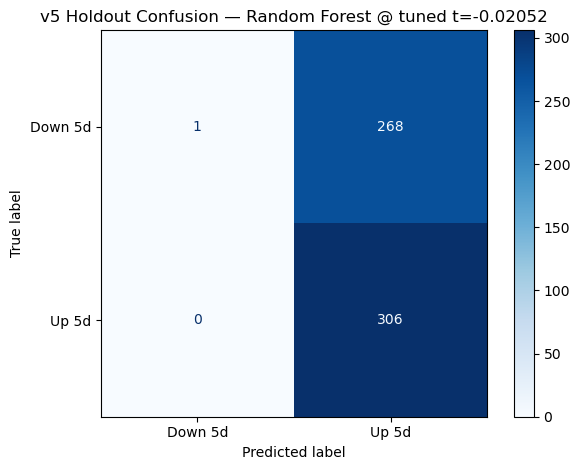

In [11]:
holdout_pred = best_reg.predict(X_holdout)
pred_up_0 = (holdout_pred > 0).astype(int)
pred_up_t = (holdout_pred > best_t).astype(int)

acc_0 = accuracy_score(y_holdout_bin, pred_up_0)
acc_t = accuracy_score(y_holdout_bin, pred_up_t)

print('HOLDOUT DIRECTIONAL ACCURACY (v5)')
print('-' * 50)
print(f'Majority-class baseline:           {maj_acc:.4f}')
print(f'Threshold = 0:                     {acc_0:.4f}')
print(f'Threshold = {best_t:+.5f} (tuned):  {acc_t:.4f}')
print()
print('confusion matrix (tuned threshold):')
print(confusion_matrix(y_holdout_bin, pred_up_t))
print()
print(f'precision: {precision_score(y_holdout_bin, pred_up_t):.4f}')
print(f'recall:    {recall_score(y_holdout_bin, pred_up_t):.4f}')
print(f'f1:        {f1_score(y_holdout_bin, pred_up_t):.4f}')

ConfusionMatrixDisplay.from_predictions(
    y_holdout_bin, pred_up_t,
    display_labels=['Down 5d','Up 5d'],
    cmap=plt.cm.Blues,
)
plt.title(f'v5 Holdout Confusion — {best_reg_name} @ tuned t={best_t:+.5f}')
plt.tight_layout()
plt.show()

## SHAP — Feature Importance with Technical Indicators

The key question: do the new technical indicators (RSI, MACD family, DistTo52wHigh) appear high in the SHAP ranking, or do they get dominated by the existing lag and exogenous features?

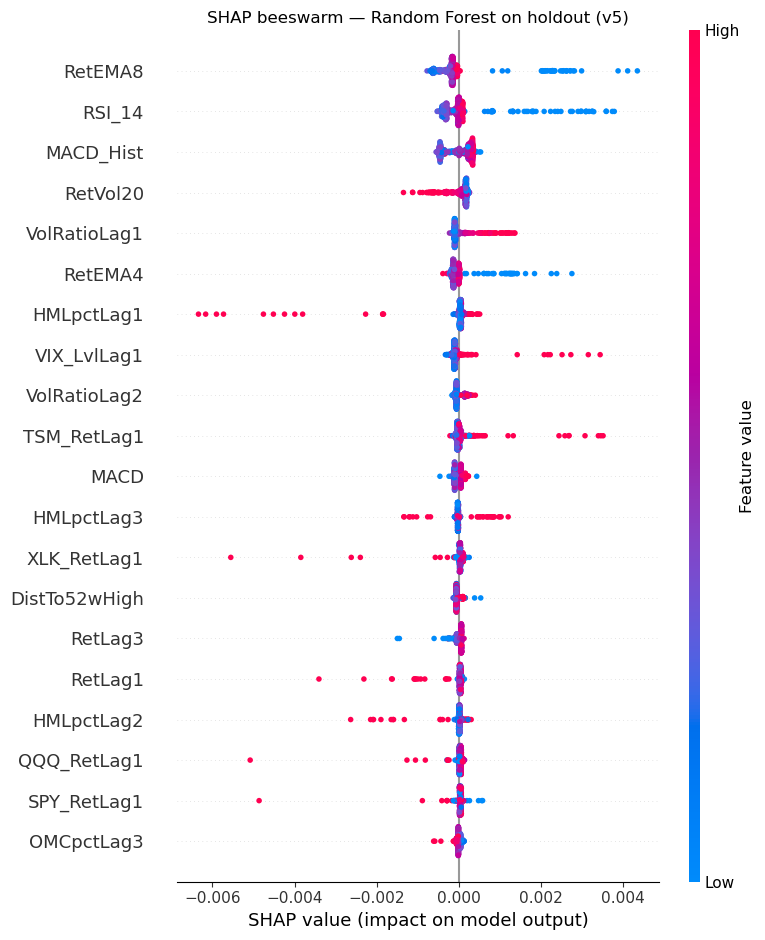

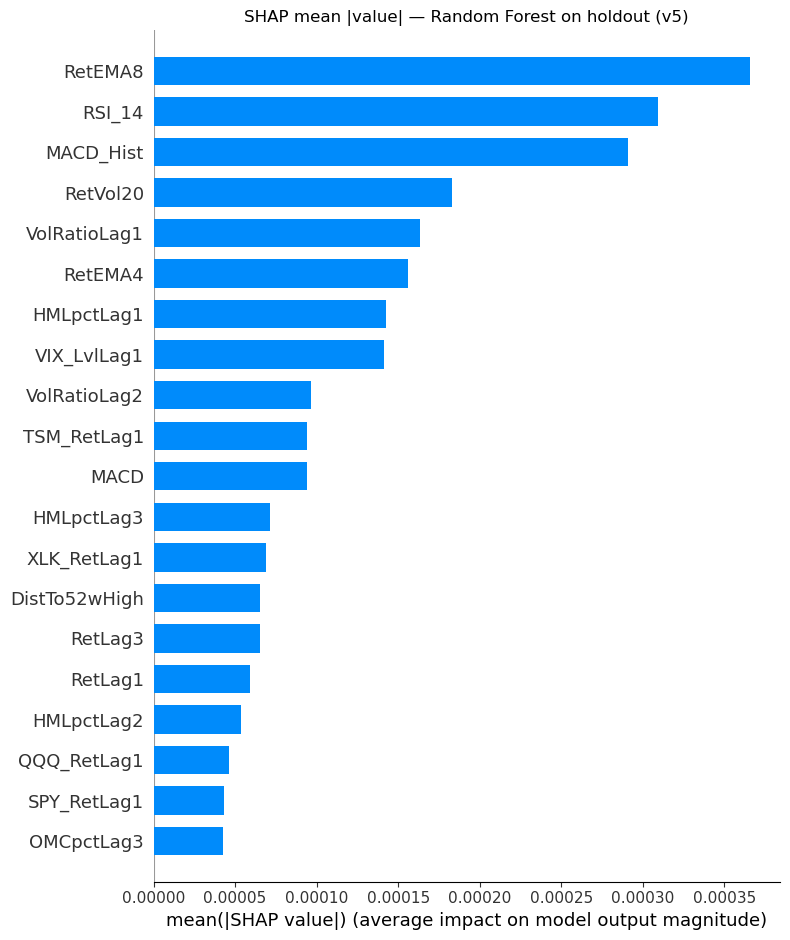

SHAP ranking (mean |SHAP|):
  1.    RetEMA8            0.000366
  2.  * RSI_14             0.000309
  3.  * MACD_Hist          0.000291
  4.    RetVol20           0.000183
  5.    VolRatioLag1       0.000163
  6.    RetEMA4            0.000156
  7.    HMLpctLag1         0.000142
  8.    VIX_LvlLag1        0.000141
  9.    VolRatioLag2       0.000097
 10.    TSM_RetLag1        0.000094
 11.  * MACD               0.000094
 12.    HMLpctLag3         0.000071
 13.    XLK_RetLag1        0.000069
 14.  * DistTo52wHigh      0.000065
 15.    RetLag3            0.000065
 16.    RetLag1            0.000059
 17.    HMLpctLag2         0.000054
 18.    QQQ_RetLag1        0.000046
 19.    SPY_RetLag1        0.000043
 20.    OMCpctLag3         0.000043
 21.    OMCpctLag1         0.000043
 22.    VIX_ChgLag1        0.000041
 23.    SOXX_RetLag1       0.000039
 24.    TNX_ChgLag1        0.000039
 25.  * MACD_Signal        0.000037
 26.    RetEMA2            0.000035
 27.    OMCpctLag2         0.000018


In [15]:
if best_reg_name in ('Random Forest', 'XGBoost'):
    explainer = shap.TreeExplainer(best_reg)
    shap_values = explainer.shap_values(X_holdout)

    shap.summary_plot(shap_values, X_holdout, feature_names=list(featureNames), show=False)
    plt.title(f'SHAP beeswarm — {best_reg_name} on holdout (v5)')
    plt.tight_layout()
    plt.show()
    plt.gcf().savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')

    shap.summary_plot(shap_values, X_holdout, feature_names=list(featureNames),
                      plot_type='bar', show=False)
    plt.title(f'SHAP mean |value| — {best_reg_name} on holdout (v5)')
    plt.tight_layout()
    plt.show()
else:
    bg = shap.sample(X_train, 200, random_state=42)
    explainer = shap.LinearExplainer(best_reg, bg)
    shap_values = explainer.shap_values(X_holdout)
    shap.summary_plot(shap_values, X_holdout, feature_names=list(featureNames), show=False)
    plt.title(f'SHAP beeswarm — {best_reg_name}')
    plt.tight_layout()
    plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_rank = sorted(zip(featureNames, mean_abs_shap), key=lambda x: x[1], reverse=True)

print('SHAP ranking (mean |SHAP|):')
tech = {'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'DistTo52wHigh'}
for i, (f, v) in enumerate(shap_rank):
    marker = '  *' if f in tech else '   '
    print(f' {i+1:2d}.{marker} {f:18s} {v:.6f}')
print()
print('  * = technical indicator added in v5')


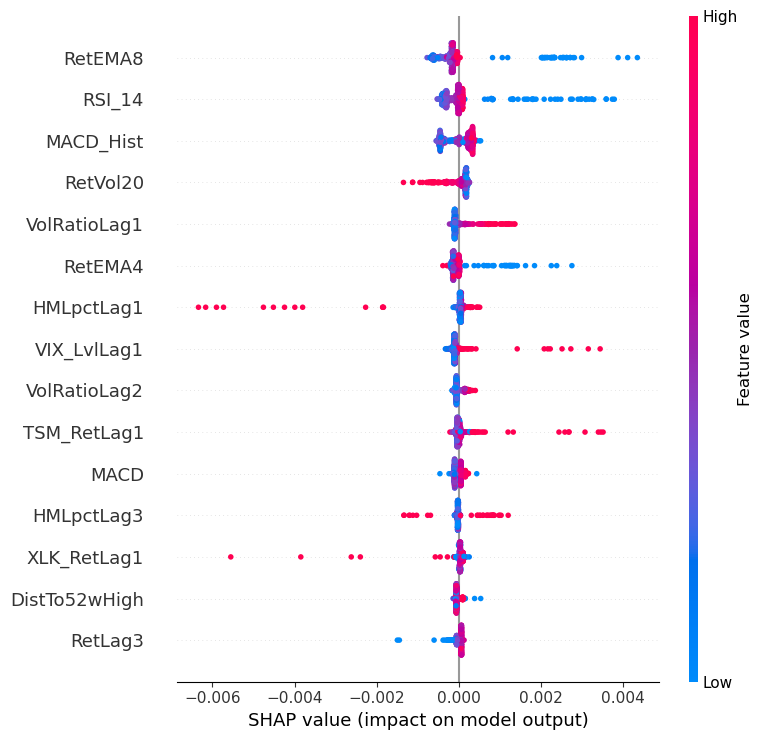

saved shap_beeswarm2.png


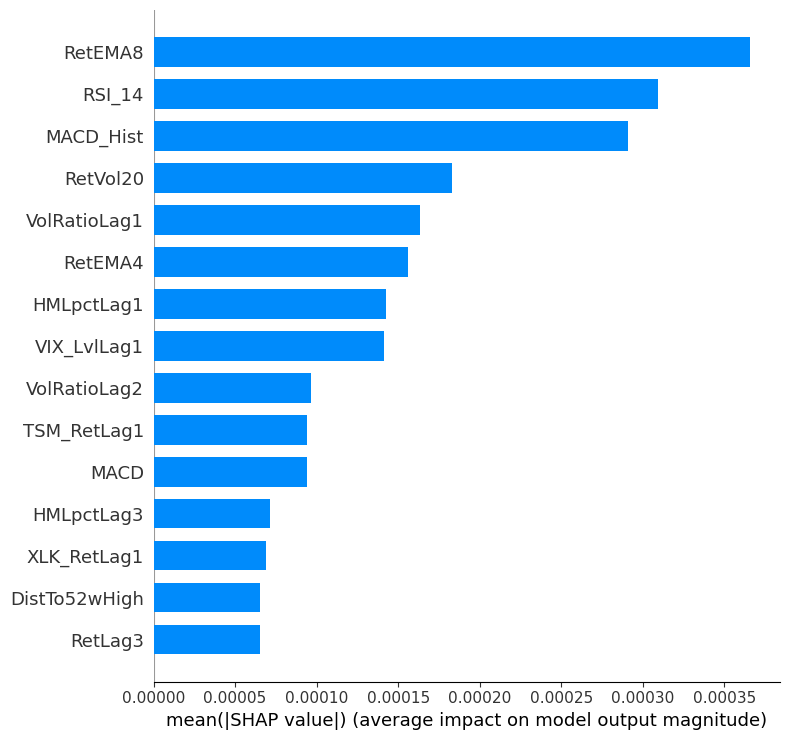

saved shap_bar.png


In [18]:
import shap
import matplotlib.pyplot as plt

# compute SHAP values 
if best_reg_name in ('Random Forest', 'XGBoost'):
    explainer = shap.TreeExplainer(best_reg)
    shap_values = explainer.shap_values(X_holdout)
else:
    bg = shap.sample(X_train, 200, random_state=42)
    explainer = shap.LinearExplainer(best_reg, bg)
    shap_values = explainer.shap_values(X_holdout)

# beeswarm, top 15 features, saved to file 
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_holdout,
    feature_names=list(featureNames),
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig('shap_beeswarm2.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved shap_beeswarm2.png')

# --- bar plot, top 15, saved to file ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_holdout,
    feature_names=list(featureNames),
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved shap_bar.png')

## Summary

v5 adds standard technical indicators (RSI(14), MACD/Signal/Histogram, Distance to 52-Week High) to the v4 regression pipeline.

Things to cover in the writeup:

1. **Did the new indicators land in the top half of the SHAP ranking?** If yes, they're contributing independent information — the model is actually using them. If they ranked near the bottom, tree models had already internalized equivalent signal from existing lag features.
2. **v4 vs v5 holdout comparison.** Fill in the v4 numbers and compare. A small improvement in IC (+0.01 to +0.02) is realistic and worth reporting. No change means technical indicators don't add independent signal on this problem — which is itself a defensible finding.
3. **Interpretation via SHAP beeswarm.** For any technical indicator that ranks high, does the SHAP plot show the expected *directional* effect? E.g. does high RSI (red dots) push predictions down (overbought → reversion), as the textbook says?
4. **Where the model still fails.** Even with technical indicators, if the holdout accuracy is still near 54–57%, the EMH framing remains intact. Technical indicators have been widely studied and arbitraged for decades — the finding that they add little incremental value on a liquid mega-cap is consistent with that literature.